# scCS Tutorial — Single-Condition Analysis
## Single-cell Commitment Scores with Radial Star Embedding

**scCS v0.5.0** computes RNA velocity-based commitment scores for k-furcation cell fate decisions.

### What scCS does
1. Takes a user-defined **bifurcation cluster** (progenitor) and **k terminal fate clusters**
2. Builds a **radial star embedding** — progenitor at origin, each fate on its own arm
3. Projects **RNA velocity** into this embedding
4. Computes **commitment scores** (unCS, nCS) and per-cell fate affinities
5. Optionally bootstraps **confidence intervals** on all scores
6. Identifies **driver genes** (velocity-based + DEG-based) per fate arm
7. Runs **pathway enrichment** (KEGG, GO BP, Reactome) per fate

### Reference
Kriukov et al. (2025) *Single-cell transcriptome of myeloid cells in response to transplantation of human retinal neurons reveals reversibility of microglial activation*

---
**Notebook outline**

| Section | What you learn |
|---------|---------------|
| 1. Installation | pip install |
| 2. Load & preprocess | scVelo pancreas dataset |
| 3. RNA velocity | scVelo dynamical model |
| 4. Build star embedding | `CommitmentScorer.build_embedding()` |
| 5. Fix arm coverage | `rebuild_embedding_with_subset_pseudotime()` |
| 6. Fit & score | `fit()`, `score()`, bootstrap CI |
| 7. Visualize | star plot, rose, pairwise heatmap, bar chart |
| 8. Per-cell scores | fate affinity, entropy, NN-smoothed entropy |
| 9. Transfer labels | write scores back to full adata |
| 10. Subset scoring | `score_per_subset()` |
| 11. Driver genes | velocity drivers, DEG drivers |
| 12. Pathway enrichment | KEGG / GO BP per fate |
| 13. Expression trends | `plot_expression_trends()` |


## 1. Installation

In [1]:
# Install from GitHub (recommended)
# !pip install git+https://github.com/mcrewcow/scCS.git

# Or from a local directory:
# !pip install -e /path/to/scCS

import scCS
print(f"scCS version: {scCS.__version__}")

scCS version: 0.5.0


## 2. Load & preprocess data

We use the built-in **pancreas** dataset from scVelo — a well-studied k=4 bifurcation
(Ductal → Alpha, Beta, Delta, Epsilon).  The dataset already contains spliced/unspliced
counts and cluster annotations.


In [2]:
import numpy as np
import pandas as pd
import anndata
import matplotlib.pyplot as plt
import scanpy as sc
import scvelo as scv

sc.settings.verbosity = 1
scv.settings.verbosity = 1

adata = scv.datasets.pancreas()
print(adata)
print("\nCluster labels:", adata.obs['clusters'].unique().tolist())

AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced'
    obsp: 'distances', 'connectivities'

Cluster labels: ['Pre-endocrine', 'Ductal', 'Alpha', 'Ngn3 high EP', 'Delta', 'Beta', 'Ngn3 low EP', 'Epsilon']


In [4]:
# Standard scVelo preprocessing
scv.pp.filter_and_normalize(adata, min_shared_counts=20, n_top_genes=2000)
sc.pp.neighbors(adata)
scv.pp.moments(adata, n_pcs=None, n_neighbors=None)

/home/baranov_lab/anaconda3/lib/python3.9/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)


## 3. RNA velocity

We run the **dynamical model** (most accurate) via scVelo.
If your data already has `velocity` and `velocity_graph`, skip this section.


  0%|          | 0/1119 [00:00<?, ?gene/s]

  0%|          | 0/3696 [00:00<?, ?cells/s]

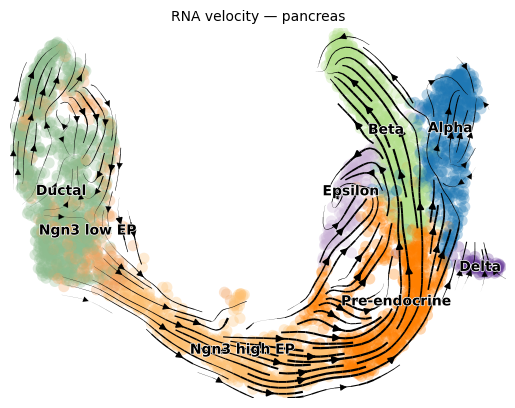

In [5]:
scv.tl.recover_dynamics(adata, n_jobs=32)
scv.tl.velocity(adata, mode="dynamical")
scv.tl.velocity_graph(adata)
scv.tl.velocity_pseudotime(adata)

# Visualise velocity on UMAP
scv.pl.velocity_embedding_stream(adata, basis="umap", color="clusters",
                                  title="RNA velocity — pancreas")

**Alternatively**, you can let scCS run the full velocity pipeline for you:

```python
scorer = scCS.CommitmentScorer(adata, ...)
scorer.compute_velocity(mode="dynamical", n_top_genes=2000)
```


## 4. Build the radial star embedding

The pancreas dataset has a clear bifurcation from **Ductal** progenitors into
four terminal fates: Alpha, Beta, Delta, Epsilon.

`CommitmentScorer` requires:
- `bifurcation_cluster` — the progenitor cluster label
- `terminal_cell_types` — list of terminal fate cluster labels
- `cluster_key` — column in `adata.obs` with cluster labels


In [29]:
scorer = scCS.CommitmentScorer(
    adata,
    bifurcation_cluster="Pre-endocrine",
    terminal_cell_types=["Alpha", "Beta", "Delta", "Epsilon"],
    cluster_key="clusters",
    n_bins=36,          # 10° angular bins (default)
    sector_mode="centroid",  # anchor sectors to fate centroids (recommended)
)

# Build the star embedding using scVelo pseudotime
scorer.build_embedding(
    differentiation_metric="pseudotime",  # uses adata.obs['velocity_pseudotime']
    arm_scale=10.0,   # maximum radial distance
    jitter=0.3,       # perpendicular noise to avoid overplotting
)

print("Embedding shape:", scorer.adata_sub.obsm["X_sccs"].shape)
print("Cells in embedding:", scorer.adata_sub.n_obs)

[scCS] Building star embedding: bifurcation='Pre-endocrine', k=4 fates, metric='pseudotime'
[scCS] Subsetting: 1876 / 3696 cells kept
       (1820 cells from other populations excluded)
       Alpha: 481 cells (fate)
       Beta: 591 cells (fate)
       Delta: 70 cells (fate)
       Epsilon: 142 cells (fate)
       Pre-endocrine: 592 cells (progenitor)

[scCS] Star embedding built → adata_sub.obsm["X_sccs"] shape: (1876, 2)
       Arm angles: {'Alpha': 0.0, 'Beta': 90.0, 'Delta': 180.0, 'Epsilon': 270.0}
[scCS] Star embedding stored in scorer.adata_sub.obsm['X_sccs']. (1876 cells)
Embedding shape: (1876, 2)
Cells in embedding: 1876


## 5. Fix arm coverage with subset-local pseudotime

**Problem:** scVelo pseudotime is computed on the *full* adata.  When we subset to
bifurcation + terminal fate cells, the pseudotime range is compressed — cells cluster
near the origin instead of spanning the full arm length.

**Solution:** `rebuild_embedding_with_subset_pseudotime()` extracts the velocity_graph
submatrix for the subset cells, recomputes pseudotime locally, scales it to [0, 1],
and rebuilds the embedding.

> **When to use `scale_01=True` vs `False`:**
> - `scale_01=True` (default) — cells span the full arm; best for single-condition analysis
> - `scale_01=False` — preserves absolute pseudotime ordering; use for multi-condition
>   comparisons where cross-condition pseudotime comparability matters


In [30]:
# Recompute pseudotime on the subset subgraph and rebuild the embedding
scorer.rebuild_embedding_with_subset_pseudotime(scale_01=True)

# Inspect the corrected pseudotime
pt_sub = scorer.adata_sub.obs["velocity_pseudotime"]
print(f"Subset pseudotime range: [{pt_sub.min():.3f}, {pt_sub.max():.3f}]")

[scCS] Recomputing pseudotime on subset (1876 / 3696 cells)...
[scCS] Used scanpy DPT as pseudotime fallback.
[scCS] Subset pseudotime scaled to [0, 1].
[scCS] Subset pseudotime stored in adata_sub.obs['velocity_pseudotime_sub']. Range: [nan, nan]
[scCS] Rebuilding star embedding with subset-local pseudotime...
[scCS] Subsetting: 1876 / 3696 cells kept
       (1820 cells from other populations excluded)
       Alpha: 481 cells (fate)
       Beta: 591 cells (fate)
       Delta: 70 cells (fate)
       Epsilon: 142 cells (fate)
       Pre-endocrine: 592 cells (progenitor)

[scCS] Star embedding built → adata_sub.obsm["X_sccs"] shape: (1876, 2)
       Arm angles: {'Alpha': 0.0, 'Beta': 90.0, 'Delta': 180.0, 'Epsilon': 270.0}
[scCS] Embedding rebuilt. Call fit() again to update the FateMap and velocity projection.
Subset pseudotime range: [0.302, 1.000]


## 6. Fit and compute commitment scores

`fit()` builds the FateMap (validates clusters, computes fate centroids, projects velocity).
`score()` computes all commitment scores.

### Key outputs in `CommitmentScoreResult`

| Attribute | Description |
|-----------|-------------|
| `pairwise_unCS` | Unnormalized CS matrix (k × k) |
| `pairwise_nCS` | Cell-count-normalized CS matrix (k × k) |
| `commitment_vector` | Fraction of velocity mass per fate |
| `population_entropy` | Population-level commitment entropy |
| `mean_cell_entropy` | Mean per-cell fate entropy |
| `per_fate_entropy` | Per-fate binary entropy |
| `cell_scores` | Per-cell fate affinity matrix (n_cells × k) |
| `bootstrap_ci` | Bootstrap CI dict (if `n_bootstrap > 0`) |


In [31]:
scorer.fit()

[scCS] Bifurcation cluster 'Pre-endocrine': 592 cells, centroid=(-0.00, -0.00)
[scCS]   Fate 'Alpha': 481 cells, centroid=(5.00, -0.01)
[scCS]   Fate 'Beta': 591 cells, centroid=(0.03, 5.00)
[scCS]   Fate 'Delta': 70 cells, centroid=(-5.00, -0.05)
[scCS]   Fate 'Epsilon': 142 cells, centroid=(-0.02, -5.00)
[scCS] FateMap built: k=4 fates
[scCS] Projecting velocity via scVelo on full adata → slicing to subset...
[scCS] Velocity projected. Shape: (1876, 2)
FateMap  (bifurcation_cluster='Pre-endocrine', k=4)
  Cluster key : 'clusters'
  Root cells  : 592
  Root centroid: (-0.005, -0.003)
  Fate 0: 'Alpha'  n_cells=481  centroid=(5.00, -0.01)  arm_angle=0.0°
  Fate 1: 'Beta'  n_cells=591  centroid=(0.03, 5.00)  arm_angle=90.0°
  Fate 2: 'Delta'  n_cells=70  centroid=(-5.00, -0.05)  arm_angle=180.0°
  Fate 3: 'Epsilon'  n_cells=142  centroid=(-0.02, -5.00)  arm_angle=270.0°


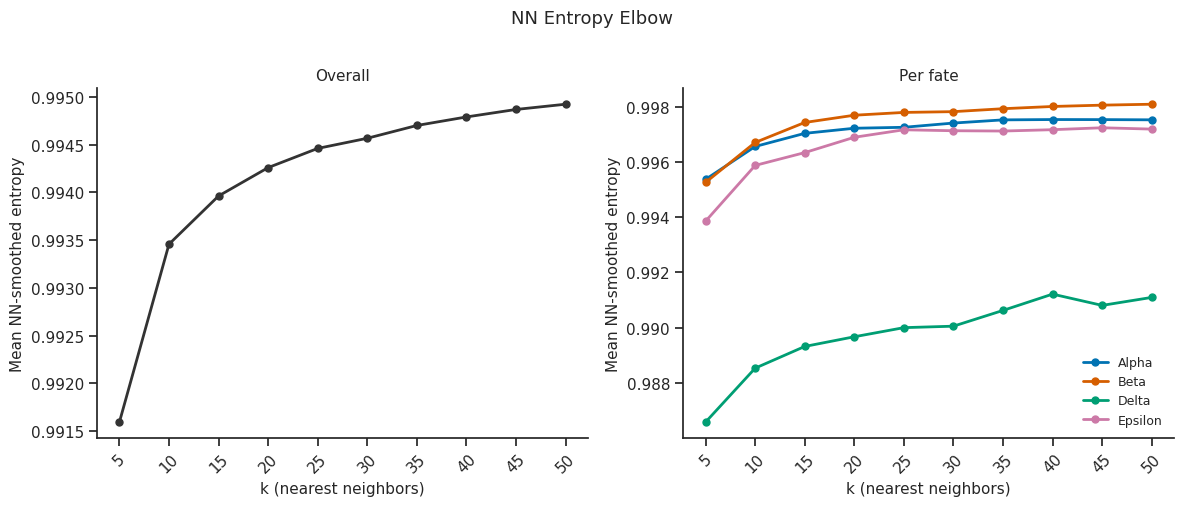

In [32]:
fig = scorer.plot_nn_entropy_elbow(k_nn_range=range(5, 51, 5))
plt.show()

In [33]:
# Score with bootstrap confidence intervals (n_bootstrap=500 recommended)
result = scorer.score(
    compute_cell_level=True,   # compute per-cell fate affinities
    k_nn=15,                   # NN-smoothed entropy (15 nearest neighbours)
    n_bootstrap=500,           # bootstrap CI on nCS
    bootstrap_ci=0.95,         # 95% CI
)

[scCS] Computing bootstrap CI (n=500)...
=== CommitmentScoreResult ===
  Fates (4): Alpha, Beta, Delta, Epsilon
  Dominant fate: Beta

  Entropy metrics:
    Population entropy:           0.9177  [aggregate velocity-mass balance]
    Mean cell entropy:            0.9736  [per-cell average, k-way]
    Per-fate cell entropy:
      Alpha: 0.8214
      Beta: 0.8153
      Delta: 0.7736
      Epsilon: 0.7654
    NN-smoothed entropy (k=15):  mean=0.9940  [per-cell, stored in adata_sub.obs['cs_nn_entropy']]

  Commitment vector (normalized):
    Alpha: 0.2805
    Beta: 0.4294
    Delta: 0.1123
    Epsilon: 0.1778

  Pairwise nCS matrix:
            Alpha      Beta     Delta   Epsilon
Alpha    1.000000  0.802707  0.363693  0.465828
Beta     1.245784  1.000000  0.453083  0.580321
Delta    2.749570  2.207100  1.000000  1.280826
Epsilon  2.146717  1.723185  0.780746  1.000000

  Bootstrap 95% CI on nCS (n=500):
    CI low:
         Alpha   Beta  Delta  Epsilon
Alpha    1.000  0.677  0.304    0.397

In [34]:
# Summary table
print(result.summary())

=== CommitmentScoreResult ===
  Fates (4): Alpha, Beta, Delta, Epsilon
  Dominant fate: Beta

  Entropy metrics:
    Population entropy:           0.9177  [aggregate velocity-mass balance]
    Mean cell entropy:            0.9736  [per-cell average, k-way]
    Per-fate cell entropy:
      Alpha: 0.8214
      Beta: 0.8153
      Delta: 0.7736
      Epsilon: 0.7654
    NN-smoothed entropy (k=15):  mean=0.9940  [per-cell, stored in adata_sub.obs['cs_nn_entropy']]

  Commitment vector (normalized):
    Alpha: 0.2805
    Beta: 0.4294
    Delta: 0.1123
    Epsilon: 0.1778

  Pairwise nCS matrix:
            Alpha      Beta     Delta   Epsilon
Alpha    1.000000  0.802707  0.363693  0.465828
Beta     1.245784  1.000000  0.453083  0.580321
Delta    2.749570  2.207100  1.000000  1.280826
Epsilon  2.146717  1.723185  0.780746  1.000000

  Bootstrap 95% CI on nCS (n=500):
    CI low:
         Alpha   Beta  Delta  Epsilon
Alpha    1.000  0.677  0.304    0.397
Beta     1.076  1.000  0.378    0.492
De

In [35]:
# Access individual scores
print("Pairwise nCS matrix:")
print(pd.DataFrame(
    result.pairwise_nCS,
    index=result.fate_names,
    columns=result.fate_names
).round(3))

print("\nCommitment vector (fraction of velocity mass per fate):")
for fate, cv in zip(result.fate_names, result.commitment_vector):
    print(f"  {fate}: {cv:.3f}")

print(f"\nPopulation entropy: {result.population_entropy:.3f}")
print(f"Mean per-cell entropy: {result.mean_cell_entropy:.3f}")

Pairwise nCS matrix:
         Alpha   Beta  Delta  Epsilon
Alpha    1.000  0.803  0.364    0.466
Beta     1.246  1.000  0.453    0.580
Delta    2.750  2.207  1.000    1.281
Epsilon  2.147  1.723  0.781    1.000

Commitment vector (fraction of velocity mass per fate):
  Alpha: 0.281
  Beta: 0.429
  Delta: 0.112
  Epsilon: 0.178

Population entropy: 0.918
Mean per-cell entropy: 0.974


In [36]:
# Bootstrap CI (if n_bootstrap > 0)
if result.bootstrap_ci is not None:
    ci = result.bootstrap_ci
    print(f"Bootstrap CI ({int(ci['ci_level']*100)}%, n={ci['n_bootstrap']}):")
    print("  nCS CI low:")
    print(pd.DataFrame(ci['ci_low'], index=result.fate_names, columns=result.fate_names).round(3))
    print("\n  nCS CI high:")
    print(pd.DataFrame(ci['ci_high'], index=result.fate_names, columns=result.fate_names).round(3))

Bootstrap CI (95%, n=500):
  nCS CI low:
         Alpha   Beta  Delta  Epsilon
Alpha    1.000  0.677  0.304    0.397
Beta     1.076  1.000  0.378    0.492
Delta    2.304  1.863  1.000    1.071
Epsilon  1.789  1.464  0.642    1.000

  nCS CI high:
         Alpha   Beta  Delta  Epsilon
Alpha    1.000  0.929  0.434    0.559
Beta     1.476  1.000  0.537    0.683
Delta    3.292  2.647  1.000    1.558
Epsilon  2.518  2.031  0.934    1.000


## 7. Visualizations

scCS provides several built-in plots.  All are accessible as methods on the scorer
or as standalone functions in `scCS.plot`.


### 7.1 Radial star embedding

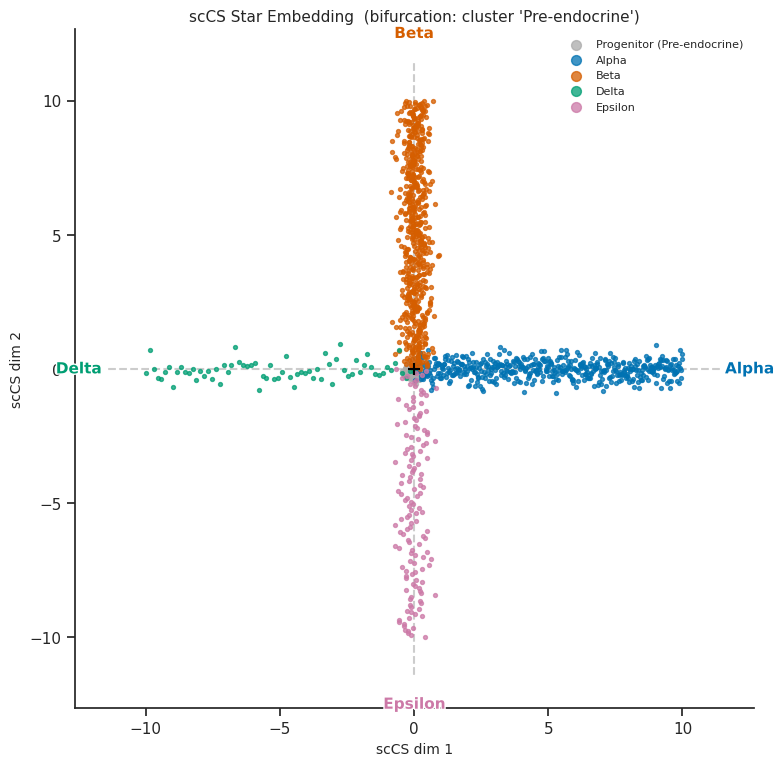

In [37]:
# Primary visualization: cells in the star embedding, coloured by fate
fig = scorer.plot_star(result, figsize=(8, 8))
plt.tight_layout()
plt.show()

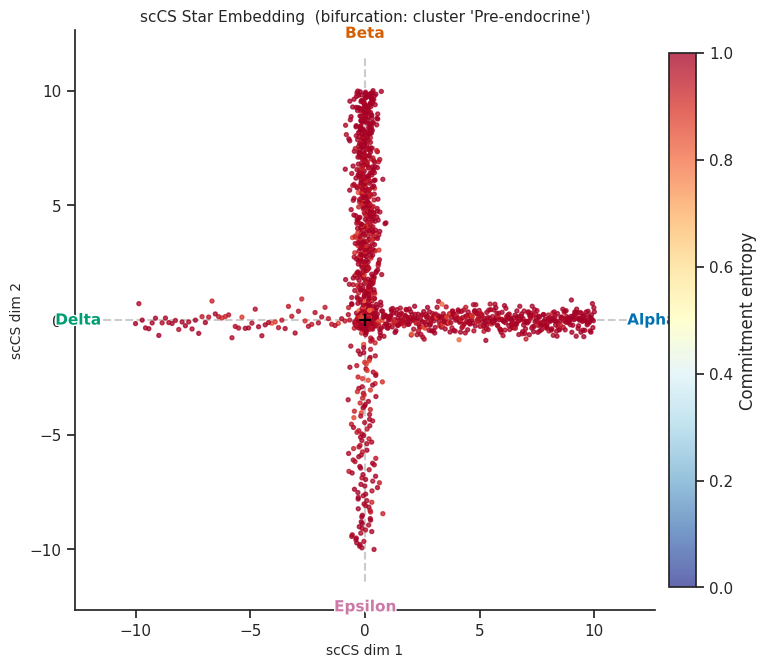

In [38]:
# Colour by per-cell entropy instead of fate
fig = scorer.plot_star(result, color_by="entropy", figsize=(8, 8))
plt.tight_layout()
plt.show()

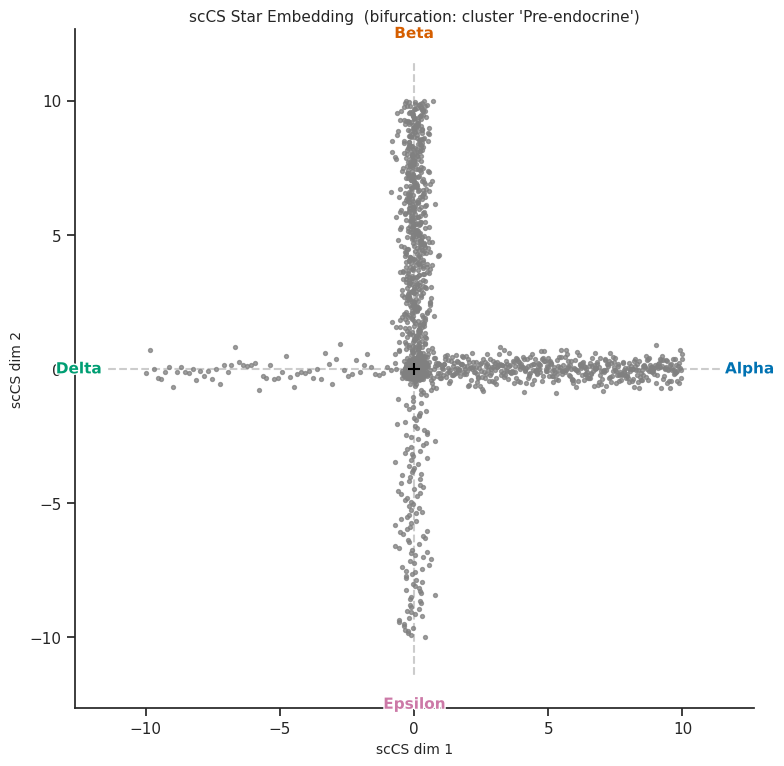

In [39]:
# Colour by NN-smoothed entropy (requires k_nn in score())
fig = scorer.plot_star(result, color_by="nn_entropy", figsize=(8, 8))
plt.tight_layout()
plt.show()

### 7.2 Rose / polar plot

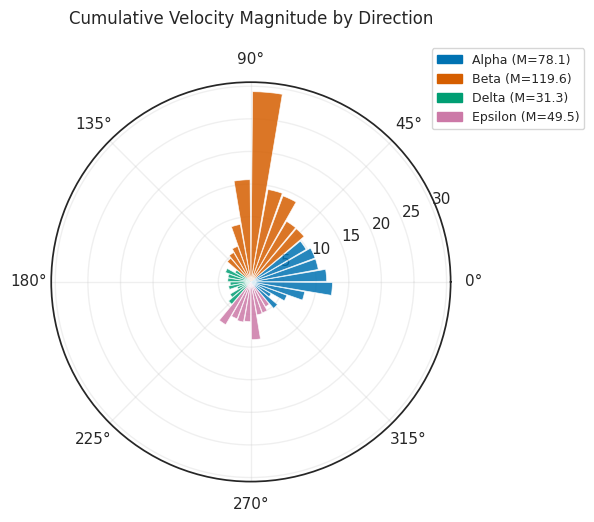

In [40]:
# Rose plot: cumulative velocity magnitude per angular bin
fig = scorer.plot_rose(result, figsize=(6, 6))
plt.tight_layout()
plt.show()

### 7.3 Pairwise nCS heatmap

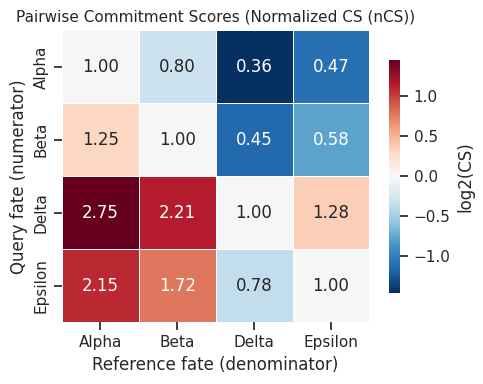

In [41]:
# Heatmap of pairwise normalized commitment scores
fig = scorer.plot_pairwise_cs(result, figsize=(5, 4))
plt.tight_layout()
plt.show()

### 7.4 Commitment bar chart

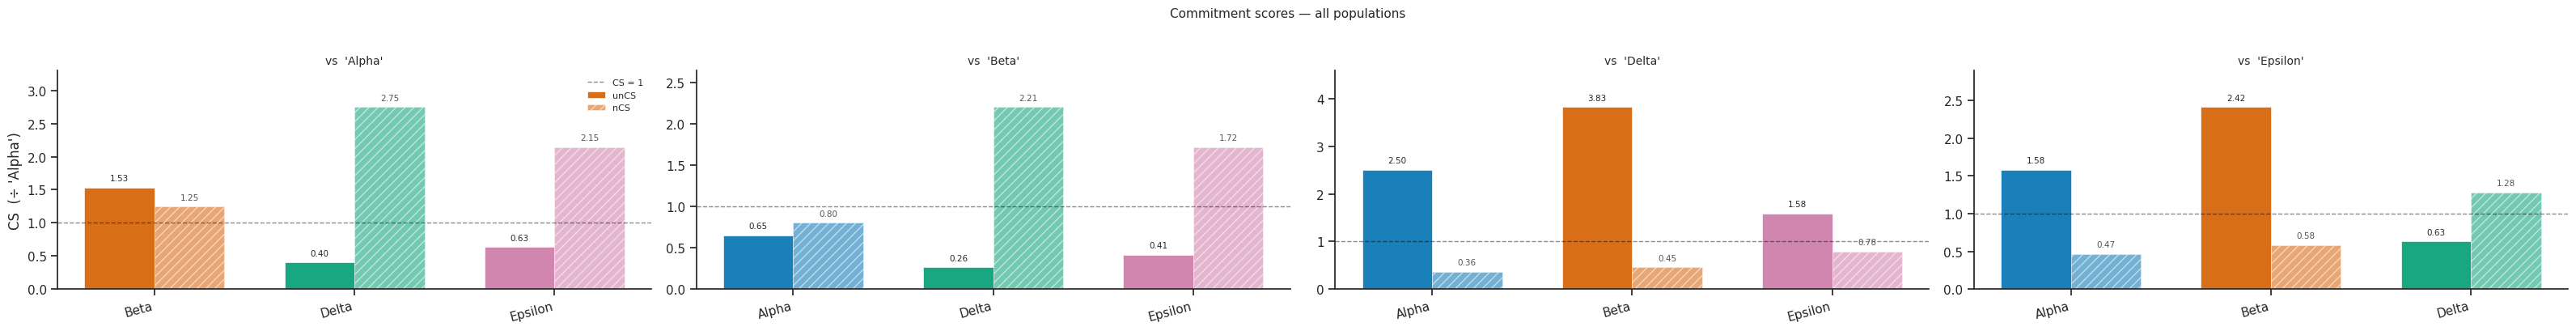

In [42]:
# Bar chart: unCS vs nCS per fate pair
fig = scorer.plot_commitment_bar(result, figsize=(8, 4))
plt.tight_layout()
plt.show()

### 7.5 Per-cell fate affinity heatmap

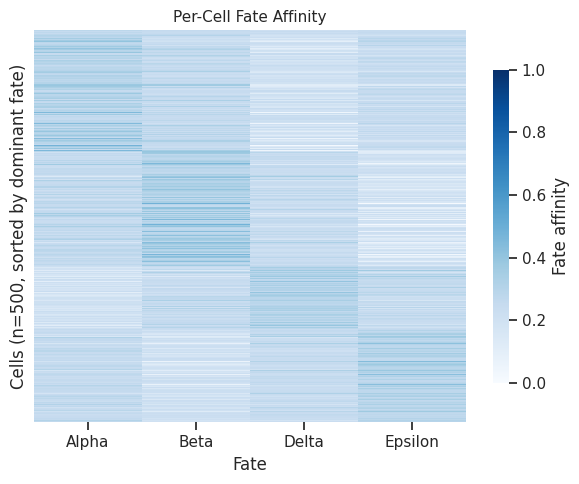

In [43]:
# Heatmap of per-cell fate affinities (rows = cells, cols = fates)
fig = scorer.plot_commitment_heatmap(result, figsize=(6, 5), max_cells=500)
plt.tight_layout()
plt.show()

### 7.6 NN entropy elbow plot

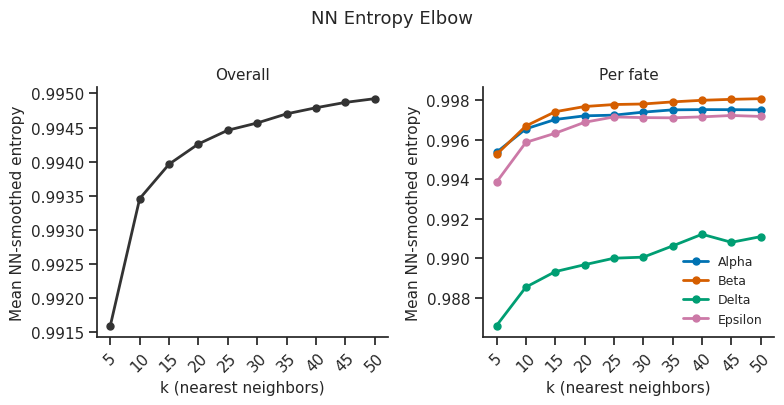

In [44]:
# Elbow plot to choose k_nn for NN-smoothed entropy
# Sweeps k_nn values and plots mean NN entropy
fig = scorer.plot_nn_entropy_elbow(k_nn_range=range(5, 51, 5), figsize=(8, 4))
plt.tight_layout()
plt.show()

## 8. Per-cell fate affinity scores

After `score(compute_cell_level=True)`, per-cell scores are stored in
`scorer.adata_sub.obs`:

| Column | Description |
|--------|-------------|
| `cs_{fate_name}` | Per-cell affinity for each fate (sums to 1 per cell) |
| `cs_dominant_fate` | Fate with highest affinity |
| `cs_entropy` | Per-cell commitment entropy (0 = fully committed, 1 = uniform) |
| `cs_nn_entropy` | NN-smoothed entropy (if `k_nn` was set) |
| `velocity_pseudotime_sub` | Subset-local pseudotime |


In [45]:
# Inspect per-cell scores
obs_cols = [c for c in scorer.adata_sub.obs.columns if c.startswith("cs_")]
print("Per-cell score columns:", obs_cols)
scorer.adata_sub.obs[obs_cols].head(10)

Per-cell score columns: ['cs_Alpha', 'cs_Beta', 'cs_Delta', 'cs_Epsilon', 'cs_dominant_fate', 'cs_entropy', 'cs_nn_entropy']


,cs_Alpha,cs_Beta,cs_Delta,cs_Epsilon,cs_dominant_fate,cs_entropy,cs_nn_entropy
index,,,,,,,
AAACCTGAGAGGGATA,0.353945,0.239385,0.145936,0.260734,Alpha,0.967483,0.989185
AAACCTGAGGCAATTA,0.250000,0.250000,0.250000,0.250000,Alpha,1.000000,0.999242
AAACCTGTCCCTCTTT,0.264720,0.243608,0.235289,0.256383,Alpha,0.999257,0.997651
AAACGGGAGTAGCGGT,0.389153,0.383790,0.109901,0.117155,Alpha,0.886326,0.994981
AAACGGGCAAAGAATC,0.287380,0.283926,0.212377,0.216317,Alpha,0.992619,0.973171
AAACGGGGTACAGTTC,0.250000,0.250000,0.250000,0.250000,Alpha,1.000000,0.995362
AAACGGGGTCGGGTCT,0.242872,0.266887,0.257050,0.233191,Beta,0.999035,0.995406
AAACGGGTCCGCGCAA,0.337151,0.402671,0.161891,0.098287,Beta,0.905747,0.985395
AAACGGGTCGCATGGC,0.269425,0.246824,0.230559,0.253192,Alpha,0.998880,0.985845


In [46]:
# Distribution of dominant fate assignments
print(scorer.adata_sub.obs["cs_dominant_fate"].value_counts())

Alpha      634
Beta       535
Epsilon    425
Delta      282
Name: cs_dominant_fate, dtype: int64


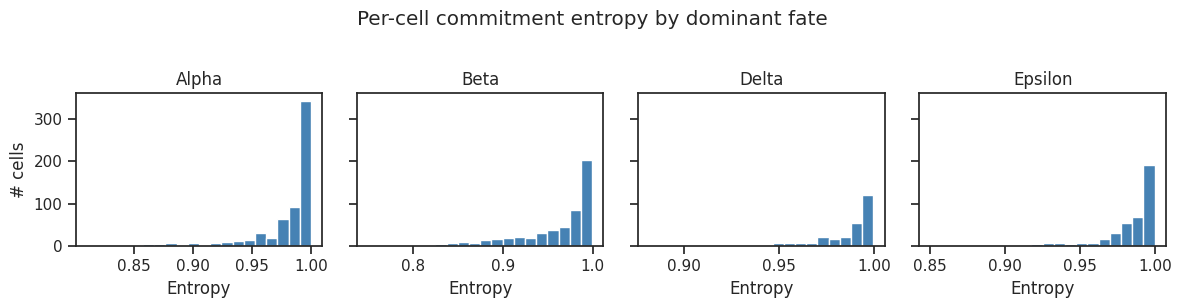

In [47]:
# Entropy distribution per fate
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(result.fate_names), figsize=(12, 3), sharey=True)
for ax, fate in zip(axes, result.fate_names):
    mask = scorer.adata_sub.obs["cs_dominant_fate"] == fate
    ax.hist(scorer.adata_sub.obs.loc[mask, "cs_entropy"], bins=20, color="steelblue", edgecolor="white")
    ax.set_title(fate)
    ax.set_xlabel("Entropy")
axes[0].set_ylabel("# cells")
plt.suptitle("Per-cell commitment entropy by dominant fate", y=1.02)
plt.tight_layout()
plt.show()

## 9. Transfer labels to full adata

`transfer_labels()` writes per-cell scores from `adata_sub` back to the full adata,
so you can use them in UMAP plots, downstream analyses, or integration with other tools.

Cells not in the embedding subset receive `NaN` (numeric) or `'unassigned'` (categorical).


In [48]:
scorer.transfer_labels(adata, result, prefix="cs_")

# Columns added to adata.obs
cs_cols = [c for c in adata.obs.columns if c.startswith("cs_")]
print("Columns added to adata.obs:", cs_cols)
adata.obs[cs_cols].head()

[scCS] Labels transferred to adata.obs for 1876 / 3696 cells. Columns: ['cs_Alpha', 'cs_Beta', 'cs_Delta', 'cs_Epsilon', 'cs_dominant_fate', 'cs_entropy']
Columns added to adata.obs: ['cs_Alpha', 'cs_Beta', 'cs_Delta', 'cs_Epsilon', 'cs_dominant_fate', 'cs_entropy', 'cs_nn_entropy']


,cs_Alpha,cs_Beta,cs_Delta,cs_Epsilon,cs_dominant_fate,cs_entropy,cs_nn_entropy
index,,,,,,,
AAACCTGAGAGGGATA,0.353945,0.239385,0.145936,0.260734,Alpha,0.967483,0.989185
AAACCTGAGCCTTGAT,NaN,NaN,NaN,NaN,unassigned,NaN,NaN
AAACCTGAGGCAATTA,0.250000,0.250000,0.250000,0.250000,Alpha,1.000000,0.999242
AAACCTGCATCATCCC,NaN,NaN,NaN,NaN,unassigned,NaN,NaN
AAACCTGGTAAGTGGC,NaN,NaN,NaN,NaN,unassigned,NaN,NaN


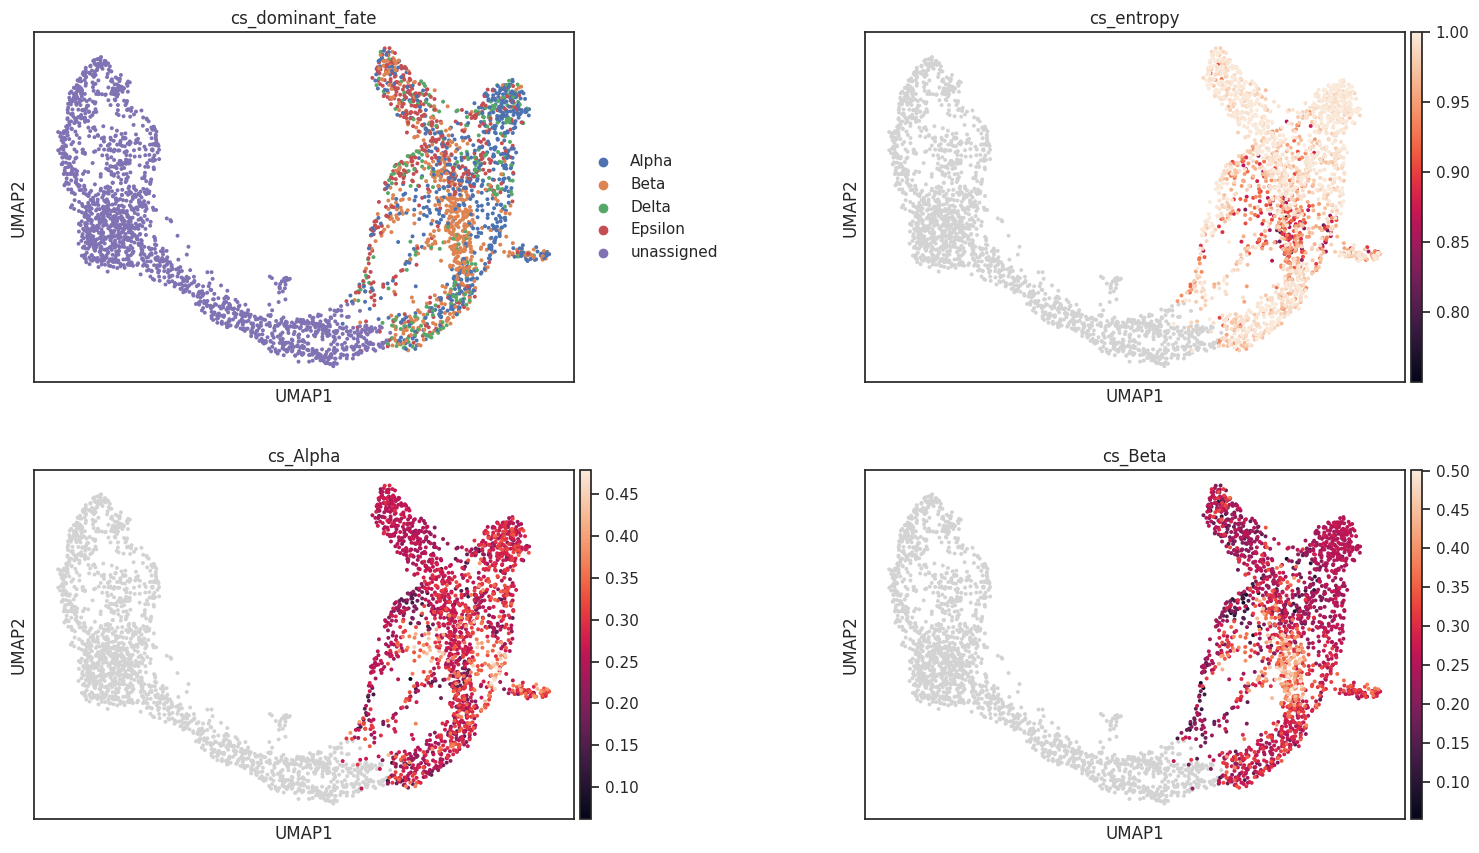

In [49]:
# Visualize on UMAP
sc.pl.umap(adata, color=["cs_dominant_fate", "cs_entropy", "cs_Alpha", "cs_Beta"],
           ncols=2, wspace=0.4)

## 10. Subset scoring

`score_per_subset()` computes commitment scores separately for each value of a
metadata column in `adata_sub.obs`.  Useful for comparing commitment across
time points, batches, or any categorical variable.

> **Note:** The mask is applied to `adata_sub` (the embedding subset), not the full adata.


In [50]:
# Example: score separately for each cluster within the embedding
# (Here we use 'clusters' as a demo; in practice use a condition/batch column)
subset_results = scorer.score_per_subset(
    subset_key="clusters",
    compute_cell_level=False,
    n_bootstrap=0,
    verbose=True,
)

# Compare nCS across subsets
print("\nnCS per subset:")
for subset_val, res in subset_results.items():
    print(f"  {subset_val}: nCS[Alpha,Beta] = {res.pairwise_nCS[0,1]:.3f}")

=== CommitmentScoreResult ===
  Fates (4): Alpha, Beta, Delta, Epsilon
  Dominant fate: Beta

  Entropy metrics:
    Population entropy:           0.8193  [aggregate velocity-mass balance]
    Mean cell entropy:            [not computed — set compute_cell_level=True]

  Commitment vector (normalized):
    Alpha: 0.2565
    Beta: 0.5440
    Delta: 0.1202
    Epsilon: 0.0793

  Pairwise nCS matrix:
         Alpha  Beta  Delta  Epsilon
Alpha      1.0   inf    inf      inf
Beta       inf   1.0    inf      inf
Delta      inf   inf    1.0      inf
Epsilon    inf   inf    inf      1.0

--- Subset: Pre-endocrine ---
=== CommitmentScoreResult ===
  Fates (4): Alpha, Beta, Delta, Epsilon
  Dominant fate: Beta

  Entropy metrics:
    Population entropy:           0.8193  [aggregate velocity-mass balance]
    Mean cell entropy:            [not computed — set compute_cell_level=True]

  Commitment vector (normalized):
    Alpha: 0.2565
    Beta: 0.5440
    Delta: 0.1202
    Epsilon: 0.0793

  Pairw

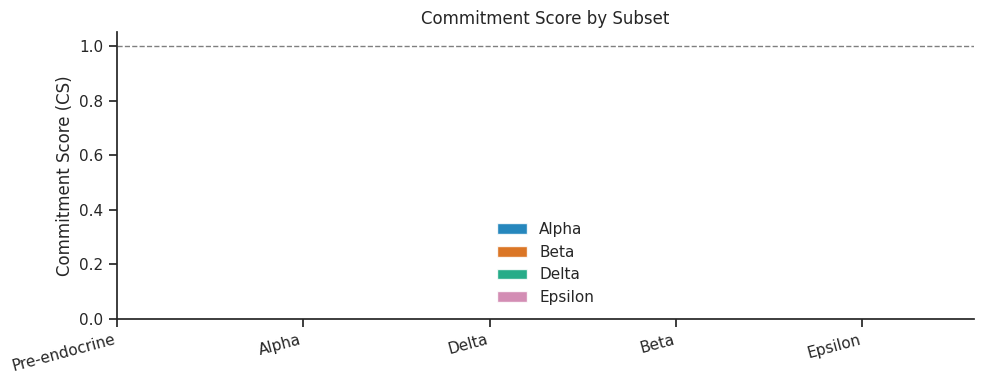

In [51]:
# Visualize subset comparison
fig = scorer.plot_subset_comparison(subset_results, figsize=(10, 4))
plt.tight_layout()
plt.show()

## 11. Driver genes

scCS provides two complementary approaches to identify fate-driving genes:

1. **Velocity drivers** — genes with highest mean RNA velocity in each fate arm
   (high positive velocity = gene is being upregulated along that fate)
2. **DEG drivers** — differentially expressed genes between each fate arm and
   the bifurcation cluster (Wilcoxon rank-sum test)


In [52]:
# Velocity-based driver genes
vel_drivers = scorer.get_velocity_drivers(n_top=20)

# Show top drivers for Alpha fate
print("Top velocity drivers — Alpha fate:")
print(vel_drivers["Alpha"].head(10).to_string(index=False))


── Velocity drivers: Alpha (top 20, sorted by delta_velocity) ──
 rank    gene  delta_velocity  mean_velocity
    1     Clu        1.488299       1.532060
    2    Cpa2        1.242302       0.851096
    3  Cryba2        1.057629       1.217163
    4    Ghrl        0.986426       0.384223
    5    Gpx2        0.960321      -0.120926
    6   Meis2        0.818967       0.663538
    7  Npepl1        0.790486       0.202400
    8  Tm4sf4        0.709575       0.473634
    9    Pax6        0.704322       0.899398
   10    Pax4        0.629620       0.037667
   11   Cd200        0.578656       0.373572
   12  Btbd17        0.577880       0.930656
   13    Krt7        0.547157      -0.280244
   14   Celf3        0.534336       0.370460
   15    Tox3        0.531873       0.241672
   16  Ppp3ca        0.492434       0.168149
   17 Gdap1l1        0.478684      -0.113692
   18    Pdx1        0.477438       0.445120
   19    Gch1        0.473593       0.565005
   20   Psmc2        0.460173     

In [53]:
# DEG-based driver genes
deg_drivers = scorer.get_deg_drivers(
    n_top=20,
    pval_cutoff=0.05,
    logfc_cutoff=0.25,
)

print("Top DEG drivers — Beta fate (vs Ductal):")
print(deg_drivers["Beta"].head(10).to_string(index=False))


── DEG drivers: Alpha vs progenitor ──
   Significant: 645  (up: 332, down: 313)
         gene  logfoldchange     pval_adj
          Tnr      25.644047 3.061043e-02
        Hpgds      25.607948 4.102013e-02
         Dpp4       5.487374 1.735167e-19
        Tgfb2       5.121229 9.323432e-03
       Pou6f2       4.746212 4.039511e-06
          Gcg       4.674589 1.064677e-63
      Ppp1r1a       4.549906 6.119348e-30
        G6pc2       4.490904 5.366586e-04
      Slc30a8       4.489614 2.503131e-21
       Slc7a2       4.168423 3.541370e-23
       Sorcs2       4.146392 6.236178e-03
      Ripply3       4.123657 1.304456e-20
         Asb4       4.076951 2.238734e-14
        Rab37       4.005985 3.024038e-24
G630016G05Rik       3.886471 5.061265e-03
         Wnk3       3.884316 1.914845e-31
   St6galnac5       3.692844 2.904467e-13
      Tmsb15l       3.663463 2.415767e-73
       Slc2a5       3.661322 2.696107e-14
        Gria2       3.519636 1.600239e-11

── DEG drivers: Beta vs progenitor 

## 12. Pathway enrichment

`get_enrichment()` runs over-representation analysis (ORA) on the DEG driver genes
for each fate using **gseapy** (KEGG, GO Biological Process, Reactome).

Requires an internet connection and a valid organism code.



  Pathway enrichment: Alpha
  Gene sets: ['KEGG_2019_Mouse', 'GO_Biological_Process_2021', 'Reactome_2022']
  Up-regulated genes  : 332
  Down-regulated genes: 313

  [up] Significant terms: 55
                  Gene_set                                                         Term Overlap  Adjusted P-value
           KEGG_2019_Mouse                                    Thyroid hormone synthesis    9/73          0.000392
           KEGG_2019_Mouse                  Protein processing in endoplasmic reticulum  13/163          0.000392
           KEGG_2019_Mouse                                                     Lysosome  11/124          0.000537
             Reactome_2022     Response To Elevated Platelet Cytosolic Ca2+ R-HSA-76005  12/130          0.000562
             Reactome_2022                          Platelet Degranulation R-HSA-114608  12/125          0.000562
             Reactome_2022    Regulation Of RUNX1 Expression And Activity R-HSA-8934593    5/17          0.001340
GO_Biol

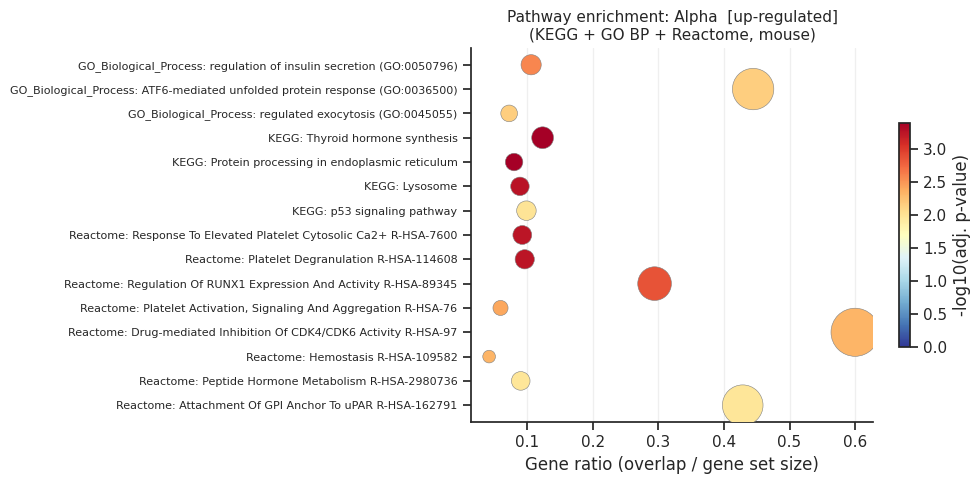

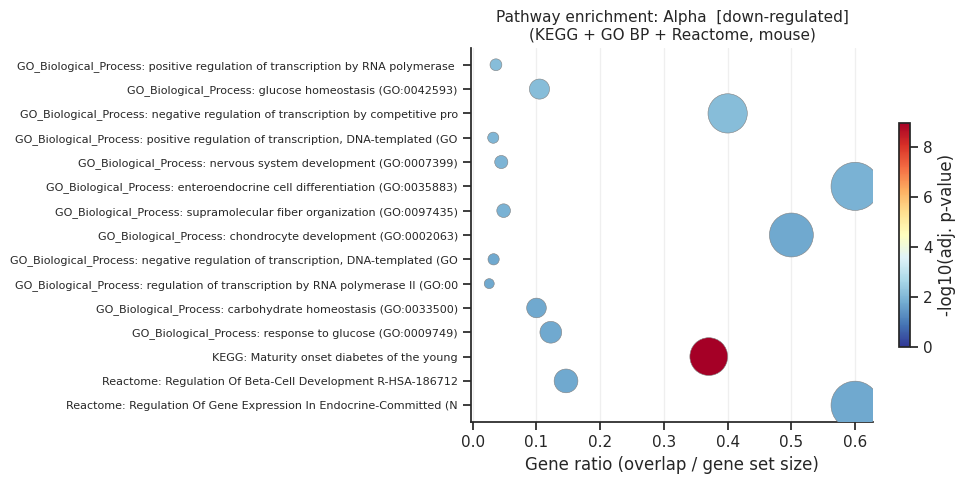


  Pathway enrichment: Beta
  Gene sets: ['KEGG_2019_Mouse', 'GO_Biological_Process_2021', 'Reactome_2022']
  Up-regulated genes  : 364
  Down-regulated genes: 295

  [up] Significant terms: 90
                  Gene_set                                                 Term Overlap  Adjusted P-value
           KEGG_2019_Mouse          Protein processing in endoplasmic reticulum  19/163      3.400034e-08
GO_Biological_Process_2021         regulation of insulin secretion (GO:0050796)  16/104      1.346279e-07
           KEGG_2019_Mouse                                    Insulin secretion   12/86      5.707466e-06
GO_Biological_Process_2021 regulation of peptide hormone secretion (GO:0090276)   12/74      6.123738e-06
GO_Biological_Process_2021         regulation of protein secretion (GO:0050708)  15/125      6.123738e-06
             Reactome_2022         Unfolded Protein Response (UPR) R-HSA-381119   12/89      5.055100e-05
           KEGG_2019_Mouse                            Thyroid ho

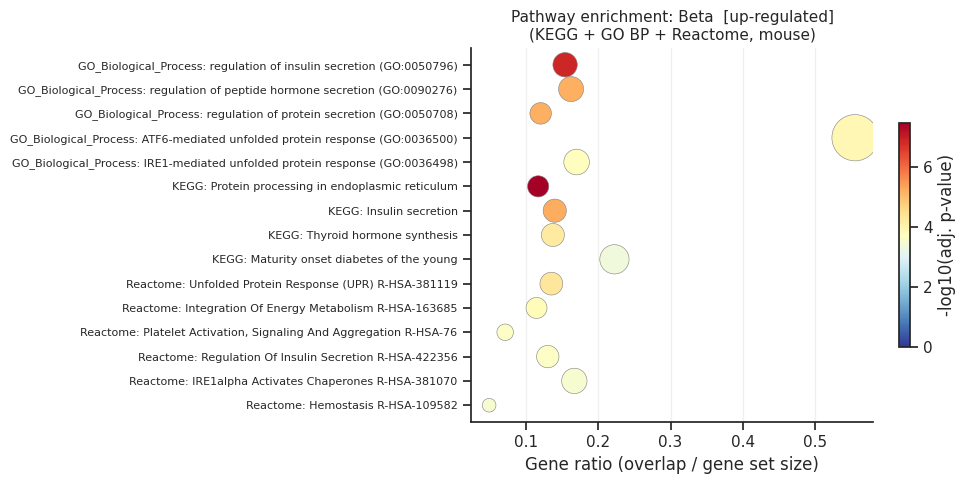

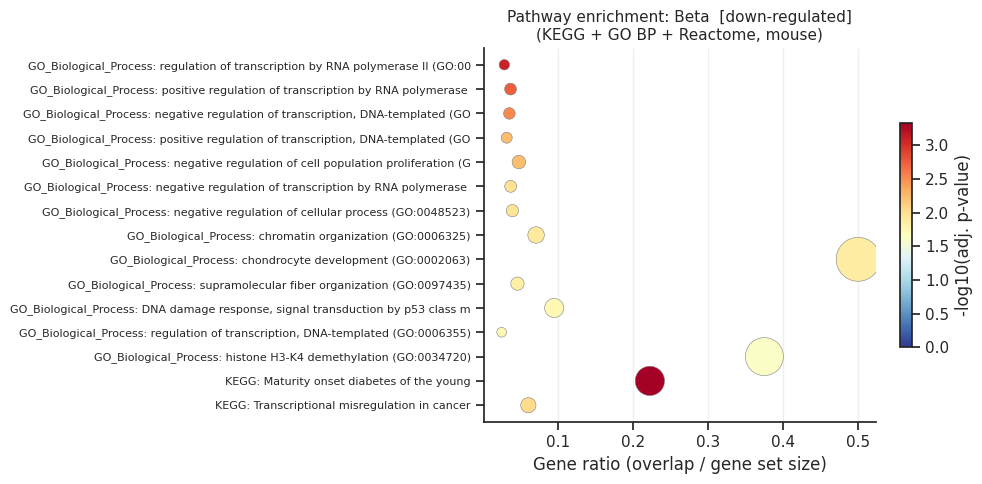


  Pathway enrichment: Delta
  Gene sets: ['KEGG_2019_Mouse', 'GO_Biological_Process_2021', 'Reactome_2022']
  Up-regulated genes  : 138
  Down-regulated genes: 178

  [up] Significant terms: 44
                  Gene_set                                                                      Term Overlap  Adjusted P-value
           KEGG_2019_Mouse                               Protein processing in endoplasmic reticulum  13/163      1.861445e-08
           KEGG_2019_Mouse                                                 Thyroid hormone synthesis    8/73      3.396605e-06
GO_Biological_Process_2021                      ATF6-mediated unfolded protein response (GO:0036500)     4/9      3.201862e-04
             Reactome_2022                                       Metabolism Of Proteins R-HSA-392499 31/1890      1.464009e-03
           KEGG_2019_Mouse                                                     Circadian entrainment    6/99      3.758396e-03
           KEGG_2019_Mouse                 

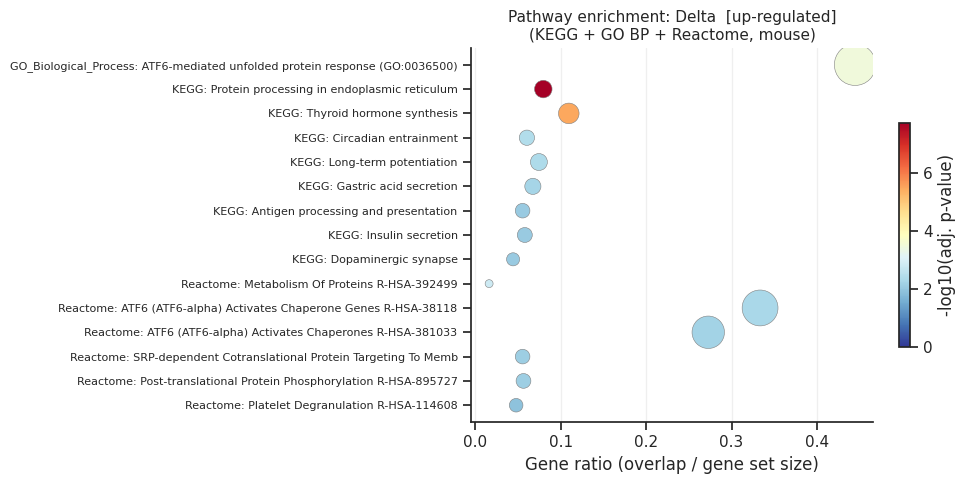

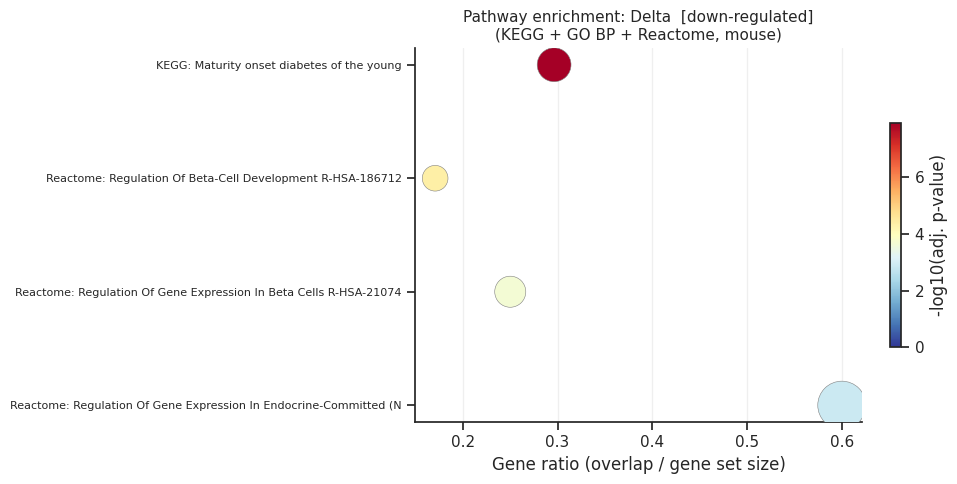


  Pathway enrichment: Epsilon
  Gene sets: ['KEGG_2019_Mouse', 'GO_Biological_Process_2021', 'Reactome_2022']
  Up-regulated genes  : 237
  Down-regulated genes: 192

  [up] Significant terms: 40
       Gene_set                                                                                      Term Overlap  Adjusted P-value
KEGG_2019_Mouse                                               Protein processing in endoplasmic reticulum  15/163      2.201289e-07
  Reactome_2022                                                  Peptide Hormone Metabolism R-HSA-2980736   10/89      5.386711e-05
  Reactome_2022 Aberrant Regulation Of Mitotic G1/S Transition In Cancer Due To RB1 Defects R-HSA-9659787    5/17      3.282394e-04
  Reactome_2022                              Incretin Synthesis, Secretion, And Inactivation R-HSA-400508    5/24      1.404617e-03
  Reactome_2022                                              Unfolded Protein Response (UPR) R-HSA-381119    8/89      1.420927e-03
  Reactome_

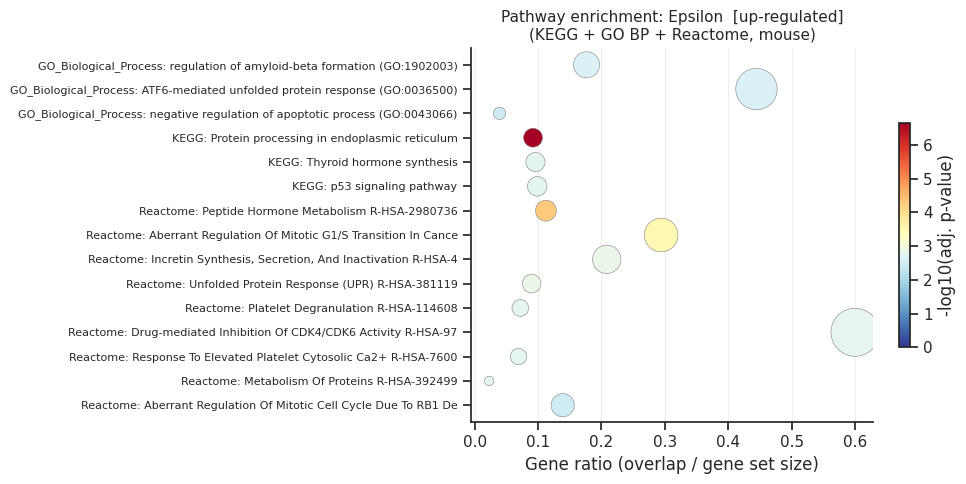

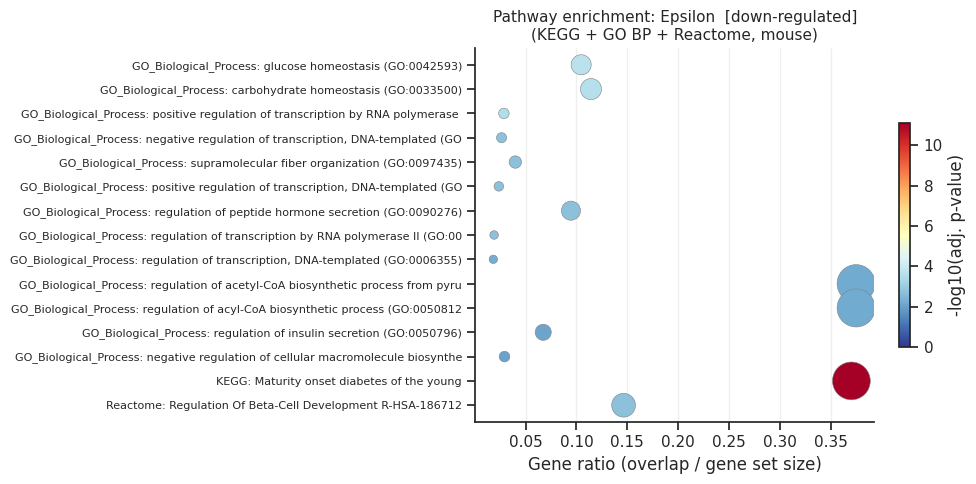


Alpha [up]: 55 significant terms
          Gene_set                                               Term Overlap  \
0  KEGG_2019_Mouse                          Thyroid hormone synthesis    9/73   
1  KEGG_2019_Mouse        Protein processing in endoplasmic reticulum  13/163   
2  KEGG_2019_Mouse                                           Lysosome  11/124   
3    Reactome_2022  Response To Elevated Platelet Cytosolic Ca2+ R...  12/130   
4    Reactome_2022                Platelet Degranulation R-HSA-114608  12/125   

   Adjusted P-value  
0          0.000392  
1          0.000392  
2          0.000537  
3          0.000562  
4          0.000562  

Alpha [down]: 27 significant terms
                     Gene_set  \
0             KEGG_2019_Mouse   
1  GO_Biological_Process_2021   
2  GO_Biological_Process_2021   
3  GO_Biological_Process_2021   
4  GO_Biological_Process_2021   

                                                Term  Overlap  \
0               Maturity onset diabetes of the 

In [59]:
# ── Pathway enrichment ────────────────────────────────────────────────────
# Note: requires gseapy and internet access for Enrichr API
# Results will be empty with synthetic data (too few significant DEGs)

try:
    enrichment = scorer.get_enrichment(
        deg_drivers,
        organism='mouse',          # 'mouse' or 'human'
        pval_cutoff=0.05,
        logfc_cutoff=0.25,
        plot=True,                 # generate dot plots automatically
        n_top_terms=15,            # top N terms per fate per direction
    )

    # Access results
    for fate_name, fate_results in enrichment.items():
        for direction in ['up', 'down']:
            df = fate_results.get(direction, None)
            if df is not None and not df.empty:
                print(f"\n{fate_name} [{direction}]: {len(df)} significant terms")
                print(df[['Gene_set', 'Term', 'Overlap', 'Adjusted P-value']].head(5))

except ImportError:
    print("gseapy not installed. Run: pip install gseapy")
except Exception as e:
    print(f"Enrichment skipped: {e}")
    print("(Expected with synthetic data — use real data for meaningful results)")


In [ ]:
# ── Custom gene sets ──────────────────────────────────────────────────────
# You can specify any Enrichr library:
# https://maayanlab.cloud/Enrichr/#libraries

custom_gene_sets = [
    'KEGG_2019_Mouse',
    'GO_Biological_Process_2021',
    'GO_Molecular_Function_2021',
    'Reactome_2022',
    'WikiPathway_2021_Mouse',
]

# enrichment = scorer.get_enrichment(
#     deg_drivers,
#     gene_sets=custom_gene_sets,
#     organism='mouse',
# )
print("Custom gene sets configured (commented out to avoid API call with synthetic data).")
print(f"Available sets: {custom_gene_sets}")


In [60]:
# Export enrichment tables to CSV
try:
    scCS.export_enrichment_tables(enrichment, output_dir="enrichment_results/")
    print("Tables saved to enrichment_results/")
except Exception as e:
    print(f"Export skipped: {e}")

Saved: enrichment_results/enrichment_Alpha_up.csv
Saved: enrichment_results/enrichment_Alpha_down.csv
Saved: enrichment_results/enrichment_Beta_up.csv
Saved: enrichment_results/enrichment_Beta_down.csv
Saved: enrichment_results/enrichment_Delta_up.csv
Saved: enrichment_results/enrichment_Delta_down.csv
Saved: enrichment_results/enrichment_Epsilon_up.csv
Saved: enrichment_results/enrichment_Epsilon_down.csv
Tables saved to enrichment_results/


## 13. Expression trends along fate arms

`plot_expression_trends()` shows how gene expression changes along each fate arm,
ordered by a differentiation metric.

The `x_axis` parameter controls the ordering:
- `'affinity'` (default) — per-cell fate affinity score
- `'pseudotime'` — subset-local pseudotime
- `'radial_distance'` — distance from origin in the star embedding


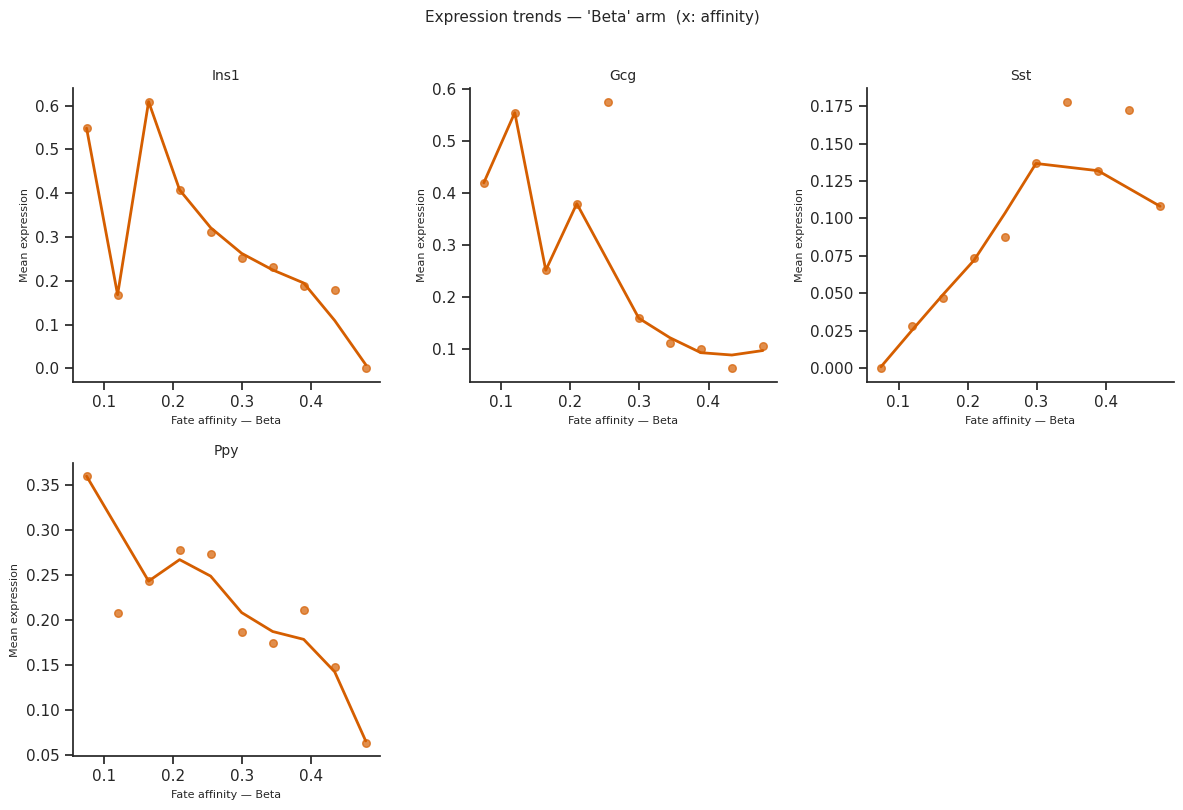

In [57]:
# Pick a few marker genes
genes_of_interest = ["Ins1", "Gcg", "Sst", "Ppy"]  # Beta, Alpha, Delta, Epsilon markers

# Expression trends ordered by fate affinity
# Signature: plot_expression_trends(adata_sub, result, genes, x_axis=...)
try:
    fig = scCS.plot_expression_trends(
        scorer.adata_sub,
        result,
        genes=genes_of_interest,
        x_axis="affinity",   # or 'pseudotime' or 'radial_distance'
        figsize=(12, 8),
    )
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Expression trends skipped: {e}")

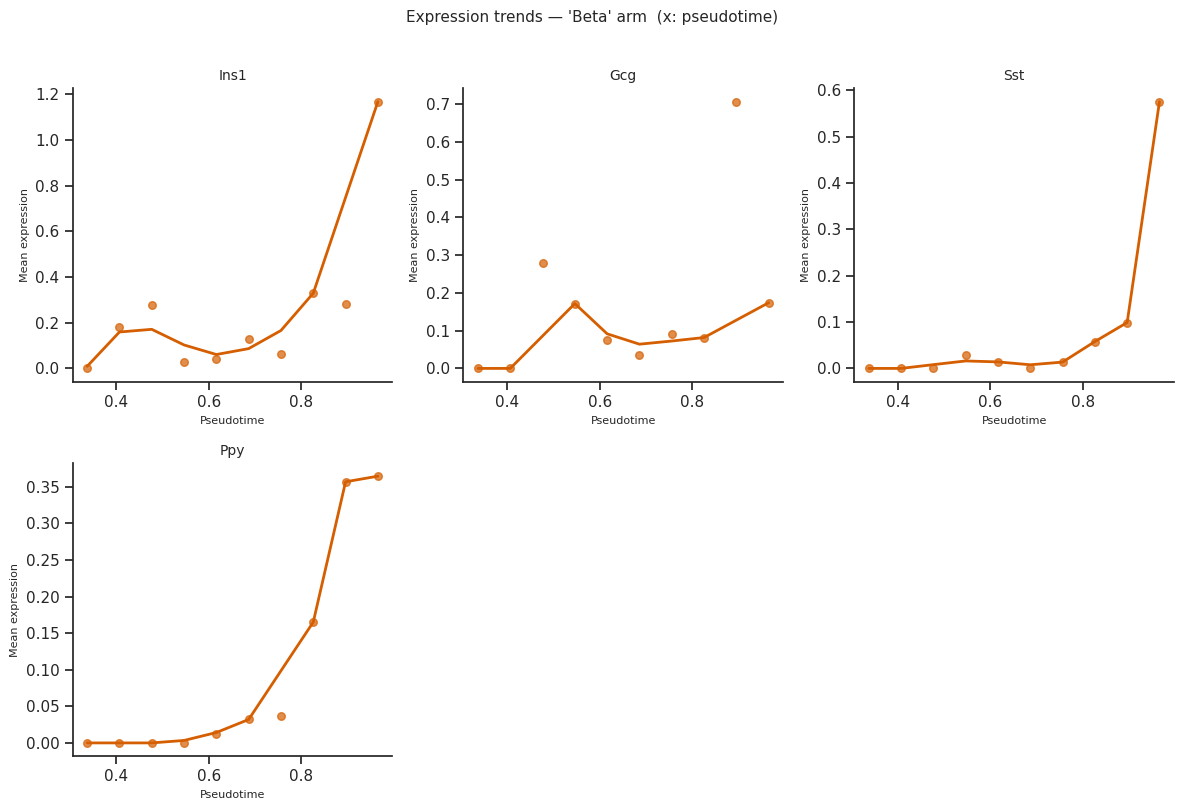

In [58]:
# Ordered by pseudotime
try:
    fig = scCS.plot_expression_trends(
        scorer.adata_sub,
        result,
        genes=genes_of_interest,
        x_axis="pseudotime",
        figsize=(12, 8),
    )
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Expression trends skipped: {e}")

In [62]:
cluster_key = "clusters"   # <-- change to your obs column

color_map = dict(zip(
    adata.obs[cluster_key].cat.categories,
    adata.uns[f"{cluster_key}_colors"],
))
print(color_map)

{'Ductal': '#8fbc8f', 'Ngn3 low EP': '#f4a460', 'Ngn3 high EP': '#fdbf6f', 'Pre-endocrine': '#ff7f00', 'Beta': '#b2df8a', 'Alpha': '#1f78b4', 'Delta': '#6a3d9a', 'Epsilon': '#cab2d6'}


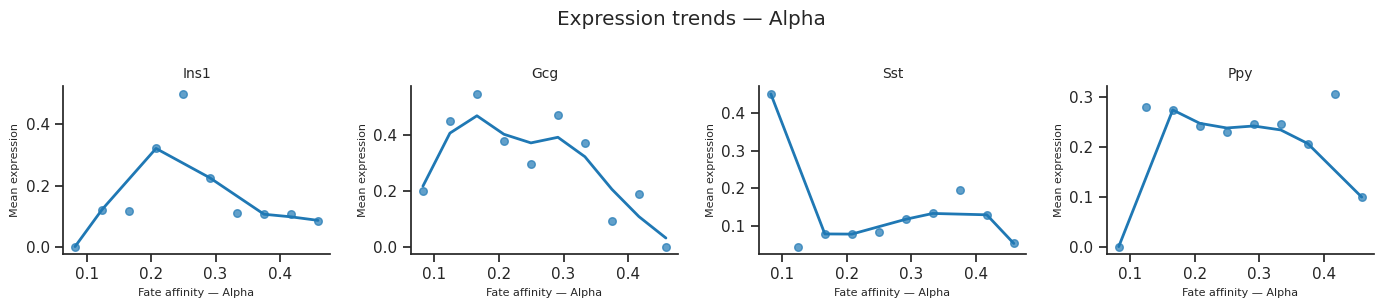

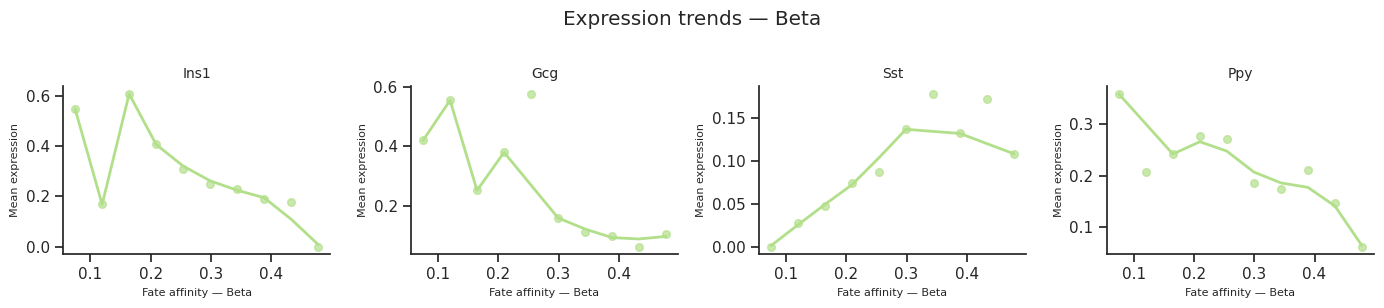

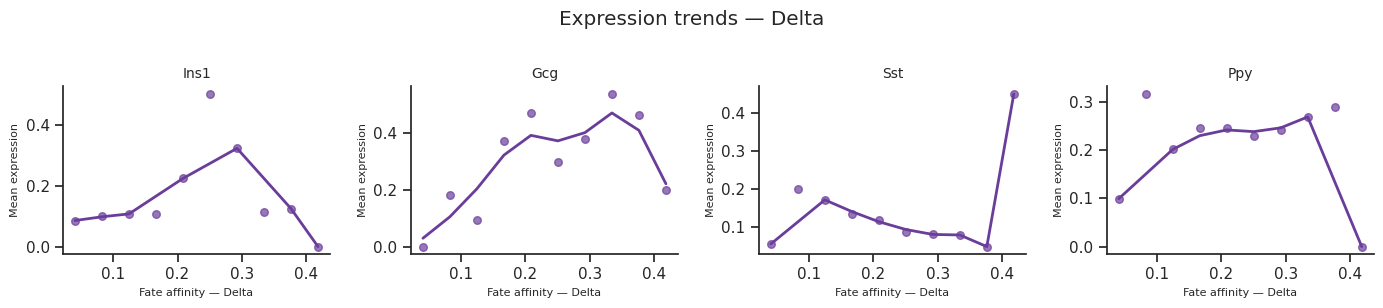

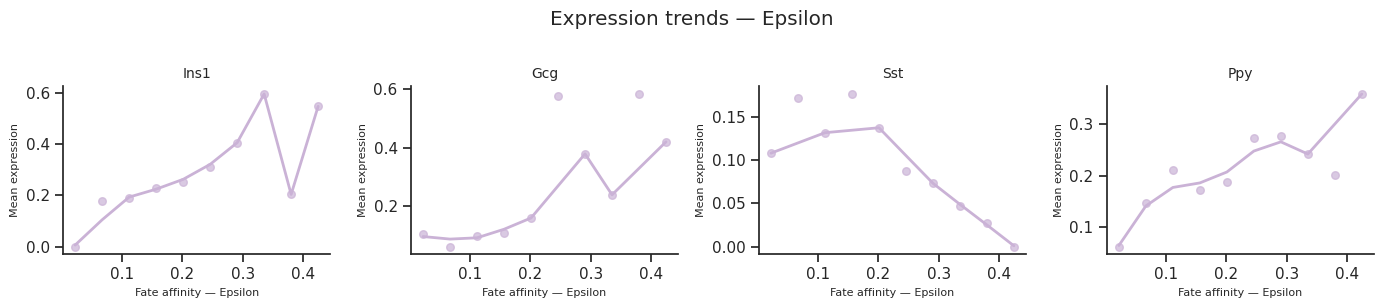

In [63]:
for fate_name in result.fate_names:
    fig = scCS.plot_expression_trends(
        adata, result,
        genes=genes_of_interest,
        fate=fate_name,
        color_map=color_map,
        ncols=4,
    )
    fig.suptitle(f"Expression trends — {fate_name}", y=1.02)
    fig.savefig(f"expression_trends_{fate_name}.svg", bbox_inches="tight")

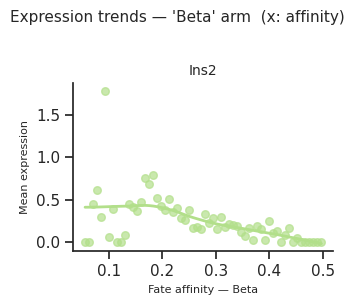

In [64]:
# CellRank-style: cells binned by per-cell CS for a chosen fate,
# mean expression per bin plotted with LOWESS smooth.
# Requires compute_cell_level=True (Cell 2 above).

genes_of_interest = ["Ins2"]   # <-- your genes

fig = scCS.plot_expression_trends(
    adata,
    result,
    genes=genes_of_interest,
    fate=result.dominant_fate,   # or e.g. fate="Activated"
    n_bins=60,                   # bins along CS axis
    layer=None,             # or None to use adata.X
    smooth=True,
    smooth_frac=0.4,             # LOWESS bandwidth (0–1)
    color_map=color_map,
    ncols=2,
)
plt.show()


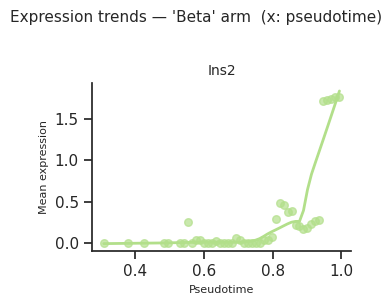

In [65]:
fig = scCS.plot_expression_trends(
    adata,
    result,
    genes=genes_of_interest,
    fate=result.dominant_fate,   # or e.g. fate="Activated"
    n_bins=60,                   # bins along CS axis
    layer=None,             # or None to use adata.X
    smooth=True,
    smooth_frac=0.4,             # LOWESS bandwidth (0–1)
    color_map=color_map,
    ncols=2, x_axis="pseudotime",
)
plt.show()

## Summary — scCS single-condition workflow

```python
import scCS

# 1. Create scorer
scorer = scCS.CommitmentScorer(
    adata,
    bifurcation_cluster="Ductal",
    terminal_cell_types=["Alpha", "Beta", "Delta", "Epsilon"],
    cluster_key="clusters",
)

# 2. Build embedding (fix arm coverage)
scorer.build_embedding(differentiation_metric="pseudotime")
scorer.rebuild_embedding_with_subset_pseudotime(scale_01=True)

# 3. Fit & score
scorer.fit()
result = scorer.score(compute_cell_level=True, k_nn=15, n_bootstrap=500)
print(result.summary())

# 4. Visualize
scorer.plot_star(result)
scorer.plot_rose(result)
scorer.plot_pairwise_cs(result)
scorer.plot_commitment_bar(result)

# 5. Transfer labels to full adata
scorer.transfer_labels(adata, result)

# 6. Driver genes & enrichment
vel_drivers = scorer.get_velocity_drivers()
deg_drivers = scorer.get_deg_drivers()
enrichment  = scorer.get_enrichment(deg_drivers, organism="Human")
```

For **multi-condition analysis**, see the companion notebook:
`scCS_tutorial_pairwise_comparison.ipynb`
